# How well do jobs and skills pay for Data Analysts?

#### Methodology
1. Evaluate median salary for top data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

#### Original Exploration

[18_Matplotlib_Box_Plots.ipynb](../2_Advanced/18_Matplotlib_Box_Plots.ipynb)  
[19_Exercise_Skill_Pay_Analysis.ipynb](../2_Advanced/19_Exercise_Skill_Pay_Analysis.ipynb)

## Import Libraries and Data

In [31]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from load_data import load_data

# Load the cleaned data_jobs dataset.
# First run downloads it from Hugging Face and caches it to data/data_jobs.parquet;
# every later run reads that cache instead. See load_data.py for the details.
df = load_data()

## Salary Distribution by Job Title

Filter our data to only include salary values from a selected country, plus a benchmark country (a large, mature market) to read the selected one against.

In [32]:
from config import SELECTED_COUNTRY, BENCHMARK_COUNTRY, MIN_SKILL_COUNT

# salaried postings for the selected market and for the benchmark market
df_country = df[(df['job_country'] == SELECTED_COUNTRY)].dropna(subset=['salary_year_avg'])
df_benchmark = df[(df['job_country'] == BENCHMARK_COUNTRY)].dropna(subset=['salary_year_avg'])

Create a list of the main job_titles in our dataset and filter our dataframe to only contain these job titles.

In [33]:
job_titles = df_country['job_title_short'].value_counts().sort_values(ascending=False)
job_titles

job_title_short
Data Scientist               24
Data Analyst                 23
Machine Learning Engineer    14
Data Engineer                13
Senior Data Engineer          9
Senior Data Scientist         8
Senior Data Analyst           5
Software Engineer             5
Cloud Engineer                1
Business Analyst              1
Name: count, dtype: int64

In [34]:
# top_jobs = 6
# job_titles = df_country['job_title_short'].value_counts().index[:top_jobs].tolist()
job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer', 'Senior Data Scientist', 'Senior Data Engineer', 'Senior Data Analyst'] # explicitly naming jobs

# filter the df for the top_jobs job titles
df_country_top = df_country[df_country['job_title_short'].isin(job_titles)]

# order the job titles by median salary
job_order = df_country_top.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

job_titles
# df_country_top
# job_order

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

## Plot Salary Distributions

Plot the top job titles salary distributions using a box plot. Each box is annotated with `n`, the number of postings it summarizes, and a crimson diamond marks the benchmark market's median for the same role.

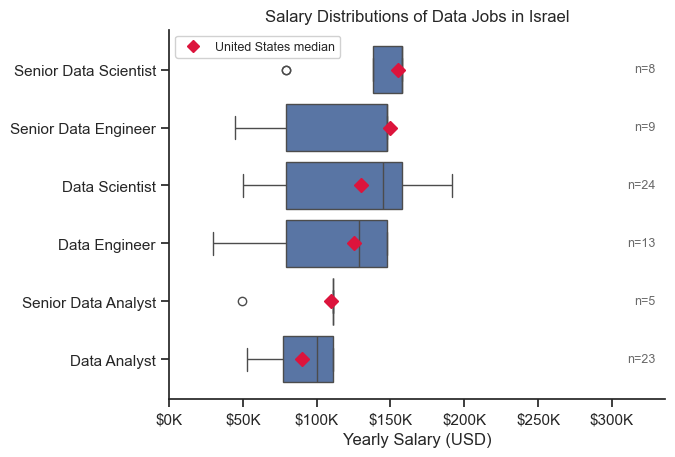

In [35]:
sns.boxplot(data=df_country_top, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
sns.despine()

# this is all the same
plt.title('Salary Distributions of Data Jobs in ' + SELECTED_COUNTRY)
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
# plt.xlim(0, 600000) # constant x limit

salary_cap = df_country_top['salary_year_avg'].quantile(0.99) # dynamic x limit
# salary_cap = df_country_top['salary_year_avg'].max() # # constant x limit, more sensitive to outliers
plt.xlim(0, salary_cap * 1.75)

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

# Show the sample size (n) at the right of each box - some are very small (e.g. n=5).
ax = plt.gca()
title_counts = df_country_top['job_title_short'].value_counts()
for i, job_title in enumerate(job_order):
    ax.text(ax.get_xlim()[1] * 0.98, i, f'n={title_counts[job_title]}',
            va='center', ha='right', fontsize=9, color='dimgray')

# Benchmark: a crimson diamond marks the median salary for the same job title in
# the benchmark market, so each distribution can be read relative to it.
if BENCHMARK_COUNTRY != SELECTED_COUNTRY:
    bench_title_median = (df_benchmark[df_benchmark['job_title_short'].isin(job_titles)]
                          .groupby('job_title_short')['salary_year_avg'].median())
    for i, job_title in enumerate(job_order):
        if job_title in bench_title_median.index:
            ax.plot(bench_title_median[job_title], i, marker='D', color='crimson', markersize=7, zorder=5)
    ax.plot([], [], marker='D', color='crimson', linestyle='', label=f'{BENCHMARK_COUNTRY} median')
    ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

plt.show()

## Investigate Median Salary Vs Skill for Data Analysts

Filters the original dataset to only get rows where the job title is 'Data Analyst' and a country of your choosing, to create a new DataFrame `df_country_da`. Drop NaN values from the 'salary_year_avg' column. Then it uses the `explode` method on the `job_skills` column to create a new row in the DataFrame for each skill associated with a job. Finally, it displays the first five entries of the `salary_year_avg` and `job_skills` columns.

In [36]:
top_n_skills = 5

# Only get data analyst jobs in the selected country
df_country_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == SELECTED_COUNTRY)].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_country_da = df_country_da.dropna(subset=['salary_year_avg'])

df_country_da = df_country_da.explode('job_skills')

df_country_da[['salary_year_avg', 'job_skills']].head(top_n_skills)

,salary_year_avg,job_skills
2818,111175.0,python
26522,111175.0,gdpr
118018,79200.0,sql
118018,79200.0,python
160995,72000.0,nosql


## Determine The Highest Paid Skills and Most Demanded Skills

Get the highest-paying skills for Data Analysts by calculating the median salary for each skill in `df_country_da`. Group by skill, compute the count and median salary, **drop any skill with fewer than `MIN_SKILL_COUNT` postings** (so the ranking isn't driven by one-off outliers), then sort by median and take the top 10.

In [37]:
df_country_da_top_pay = df_country_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

# Apply the reliability floor before ranking, and report what it removed.
n_skills_all = len(df_country_da_top_pay)
df_country_da_top_pay = df_country_da_top_pay[df_country_da_top_pay['count'] >= MIN_SKILL_COUNT]
print(f'{len(df_country_da_top_pay)} of {n_skills_all} skills have >= {MIN_SKILL_COUNT} postings '
      f'(dropped {n_skills_all - len(df_country_da_top_pay)}).')

df_country_da_top_pay = df_country_da_top_pay.sort_values(by='median', ascending=False).head(10)

df_country_da_top_pay

3 of 17 skills have >= 5 postings (dropped 14).


,count,median
job_skills,,
python,14,111175.0
sql,17,100500.0
tableau,6,95187.5


Calculate the count and median salary for each skill in `df_country_da`. Group by `job_skills`, apply the same `MIN_SKILL_COUNT` floor, sort by count to get the most in-demand skills, then re-sort that subset by median salary.

In [38]:
df_country_da_top_skills = df_country_da.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

# Same reliability floor as the highest-paid table above.
df_country_da_top_skills = df_country_da_top_skills[df_country_da_top_skills['count'] >= MIN_SKILL_COUNT]

df_country_da_top_skills = df_country_da_top_skills.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False)

df_country_da_top_skills

,count,median
job_skills,,
python,14,111175.0
sql,17,100500.0
tableau,6,95187.5


Creates two horizontal bar charts:
1. Displays the highest paid skills
2. Shows the most in demand skills

Each bar is annotated with `n`, the number of postings behind that median salary, and a crimson diamond marks the benchmark market's median for that skill.

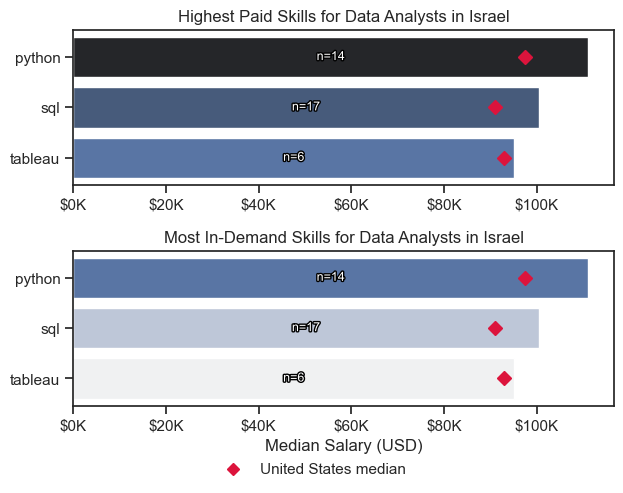

In [39]:
fig, ax = plt.subplots(2, 1)  

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_country_da_top_pay, x='median', y=df_country_da_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# original code:
# df_country_da_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Highest Paid Skills for Data Analysts in ' + SELECTED_COUNTRY)
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analysts')
sns.barplot(data=df_country_da_top_skills, x='median', y=df_country_da_top_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
# original code:
# df_country_da_top_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Most In-Demand Skills for Data Analysts in ' + SELECTED_COUNTRY)
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# Print the sample size (n) in the middle of each bar, so a high median backed by
# only a few postings is obvious at a glance. The white text gets a thin dark
# outline so it stays readable on both dark and light bars.
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

def label_counts(axis, data):
    for row_pos, (_, row) in enumerate(data.iterrows()):
        axis.text(row['median'] / 2, row_pos, f"n={int(row['count'])}",
                  va='center', ha='center', color='white', fontsize=9,
                  path_effects=[pe.withStroke(linewidth=2, foreground='black')])

label_counts(ax[0], df_country_da_top_pay)
label_counts(ax[1], df_country_da_top_skills)

# Benchmark: crimson diamond = median for the same skill in the benchmark market.
if BENCHMARK_COUNTRY != SELECTED_COUNTRY:
    bench_skill_median = (df_benchmark[df_benchmark['job_title_short'] == 'Data Analyst']
                          .explode('job_skills').groupby('job_skills')['salary_year_avg'].median())

    def mark_benchmark(axis, data):
        for row_pos, (skill, _) in enumerate(data.iterrows()):
            if skill in bench_skill_median.index:
                axis.plot(bench_skill_median[skill], row_pos, marker='D', color='crimson', markersize=7, zorder=5)

    mark_benchmark(ax[0], df_country_da_top_pay)
    mark_benchmark(ax[1], df_country_da_top_skills)
    fig.legend(handles=[Line2D([], [], marker='D', color='crimson', linestyle='',
                               label=f'{BENCHMARK_COUNTRY} median')],
               loc='lower center', bbox_to_anchor=(0.5, -0.04), frameon=False)

sns.set_theme(style='ticks')
plt.tight_layout()
plt.show()

### Selected market vs benchmark

The charts give the shape of the comparison; this compact table gives the exact medians and the percentage gap, for the skills that cleared the `MIN_SKILL_COUNT` reliability floor.

In [40]:
# Exact figures behind the charts: selected market vs benchmark, salary-reliable skills only.
selected_country_skill = df_country_da.groupby('job_skills')['salary_year_avg'].agg(count='count', median='median')
selected_country_skill = selected_country_skill[selected_country_skill['count'] >= MIN_SKILL_COUNT]

benchmark_country_skill = (df_benchmark[df_benchmark['job_title_short'] == 'Data Analyst']
                           .explode('job_skills').groupby('job_skills')['salary_year_avg'].agg(count='count', median='median'))

skill_comparison = selected_country_skill.join(benchmark_country_skill, lsuffix=f' ({SELECTED_COUNTRY})',
                                               rsuffix=f' ({BENCHMARK_COUNTRY})', how='left')
skill_comparison[f'{SELECTED_COUNTRY} vs {BENCHMARK_COUNTRY} %'] = (
    skill_comparison[f'median ({SELECTED_COUNTRY})'] / skill_comparison[f'median ({BENCHMARK_COUNTRY})'] - 1) * 100

skill_comparison.sort_values(f'median ({SELECTED_COUNTRY})', ascending=False).round(1)

,count (Israel),median (Israel),count (United States),median (United States),Israel vs United States %
job_skills,,,,,
python,14,111175.0,1431,97500.0,14.0
sql,17,100500.0,2508,91000.0,10.4
tableau,6,95187.5,1364,92875.0,2.5
